In [2]:
import os
import pymysql
import pandas as pd
import matplotlib.pyplot as plt

# CONFIGURAR / ADAPTAR ...
host = "localhost"
port = 3306
user = "root"
password = ""
database = "universidade"

conn = pymysql.connect(
    host=host,
    port=int(port),
    user=user,
    passwd=password,
    db=database,
    charset='utf8mb4')

# ADAPTAR
df = pd.read_sql_query("SELECT * FROM aluno", conn)

df.tail(10)

C:\Users\erica\AppData\Local\Temp\ipykernel_29684\725092513.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT * FROM aluno", conn)


,nr_aluno,nome,apelido,curso,media_entrada,curso_concluido,media_final
1750,200719,Maria João,Pereira,Psicologia,10.0,1,19.0
1751,20031555,Rodrigo,da Silva,Psicologia,10.0,1,19.0
1752,2003675,Marta,Capicua,Comunicação,19.0,1,10.0
1753,20201230,Lucas,Sampaio,Psicologia,20.0,1,12.0
1754,2003850,Rita,Pereira,Comunicação,19.0,1,11.0
1755,2019869,Alice,Laranjeira,Informática,11.0,1,17.0
1756,20221093,Patrícia,Pereira,Comunicação,14.0,1,16.0
1757,20071160,Lucas,Capicua,Informática,12.0,1,20.0
1758,2020288,Pedro,Capicua,Comunicação,13.0,1,19.0
1759,2019163820,Diana,da Silva,Comunicação,13.0,1,18.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1760 entries, 0 to 1759
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   nr_aluno         1760 non-null   str    
 1   nome             1760 non-null   str    
 2   apelido          1760 non-null   str    
 3   curso            1756 non-null   str    
 4   media_entrada    1760 non-null   float64
 5   curso_concluido  1760 non-null   str    
 6   media_final      1743 non-null   float64
dtypes: float64(2), str(5)
memory usage: 96.4 KB


In [4]:
df.describe()

,media_entrada,media_final
count,1760.000000,1743.000000
mean,15.031818,14.876076
std,3.398510,3.464535
min,-20.000000,-20.000000
25%,12.000000,12.000000
50%,15.000000,15.000000
75%,18.000000,18.000000
max,22.000000,21.000000


In [5]:
df.head()

,nr_aluno,nome,apelido,curso,media_entrada,curso_concluido,media_final
0,20031358,Leonardo,Pires,Psicologia,15.0,1,16.0
1,2022158,Raquel,Laranjeira,Informática,17.0,1,11.0
2,2003812,Anne,Silva,Informática,16.0,1,16.0
3,2022901,Patrícia,Castelo-Branco,Informática,11.0,1,17.0
4,2019303,Avelino,Sampaio,Comunicação,13.0,1,18.0


In [6]:
df[['media_entrada', 'media_final']].value_counts()

media_entrada  media_final
 15.0           16.0          54
 17.0           13.0          54
 16.0           14.0          54
 14.0           16.0          54
                14.0          53
 15.0           14.0          51
 12.0           19.0          51
 20.0           13.0          49
 14.0           15.0          49
 17.0           11.0          47
 13.0           20.0          47
 20.0           12.0          47
 10.0           20.0          46
 11.0           17.0          45
 10.0           19.0          45
 18.0           10.0          45
 15.0           15.0          45
 18.0           11.0          44
 16.0           16.0          43
 17.0           10.0          43
 19.0           13.0          43
                12.0          43
 10.0           18.0          42
 20.0           10.0          40
                11.0          40
 17.0           12.0          39
 12.0           20.0          38
 13.0           19.0          38
 11.0           20.0          38
 19.0           

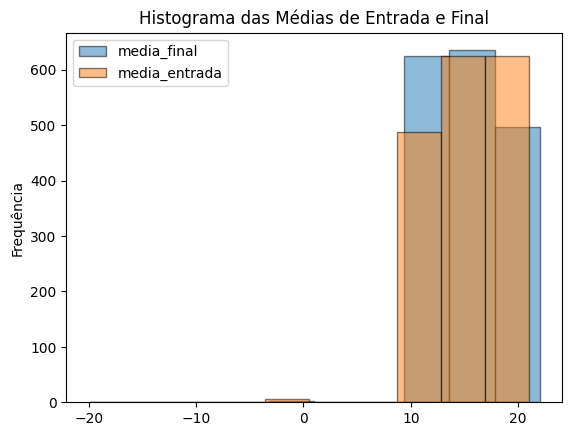

In [ ]:
fig, ax = plt.subplots()
ax.hist(df[[ 'media_entrada']], bins=10, edgecolor='black', alpha=0.5, label='Média de Entrada')
ax.set_title('Histograma das Médias de Entrada e Final')
ax.set_ylabel('Frequência')
ax.hist(df[[ 'media_final']], bins=10, edgecolor='black', alpha=0.5, label='Média Final')
ax.legend(df.columns[[6, 4]])
plt.show()



Text(0.5, 1.0, 'Média de Entrada vs Média Final')

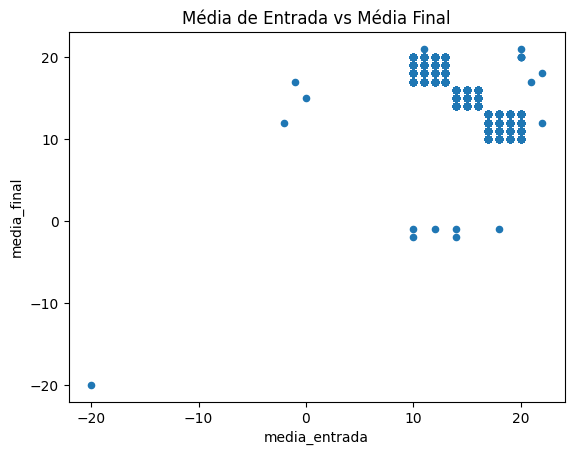

In [26]:
df.plot(x='media_entrada', y='media_final', kind='scatter')
plt.title('Média de Entrada vs Média Final')

In [33]:
df.corr(numeric_only=True)

,media_entrada,media_final
media_entrada,1.000000,-0.696457
media_final,-0.696457,1.000000


In [34]:
df.groupby('curso').agg({'media_final': 'mean'})

,media_final
curso,
Cintilar,-20.000000
Comunicação,15.048301
Desconhecido,15.500000
Informática,14.902062
Medicina Veterinária,16.000000
Má Vida,20.000000
Psicologia,14.722034
